# 勇者傳說 — Overworld Character Generator (T4 GPU)

Generate **front-facing standing pose** character sprites for overworld use.
These single 64×96 images are assembled into full spritesheets by `AICharacterAssembler.ts`.

| Category | Count | Final Size | Gen Size | Steps |
|----------|-------|------------|----------|-------|
| Party members | 8 | 64×96 | 512×768 | 28 |
| NPC types | 5 | 64×96 | 512×768 | 25 |
| Guard base | 1 | 64×96 | 512×768 | 25 |

**Output**: `overworld_characters/` → 14 RGBA PNGs
**Import**: `bash scripts/import_colab_assets.sh <output_dir>`

## 1. Setup

In [1]:
!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, os, time
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')
MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import torch
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
    DEVICE = 'cuda'
    DTYPE = torch.float16
    print(f'GPU: {name} ({vram:.1f} GB VRAM)')
else:
    DEVICE = 'cpu'
    DTYPE = torch.bfloat16
    print('WARNING: No GPU! Generation will be very slow.')

print(f'Output: {OUTPUT_BASE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 73.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but y

## 2. Utilities

In [2]:
class ProgressTracker:
    """Track completed items so we can resume after interruption."""
    def __init__(self, name, base_dir):
        self.path = Path(base_dir) / f'_progress_{name}.json'
        self.done = set()
        if self.path.exists():
            try:
                self.done = set(json.loads(self.path.read_text()))
            except Exception:
                pass

    def is_done(self, key):
        return key in self.done

    def mark_done(self, key):
        self.done.add(key)
        self.path.write_text(json.dumps(sorted(self.done)))

    def summary(self, total):
        return f'{len(self.done)}/{total} done'


def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def print_vram(label=''):
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1024**3
        total = torch.cuda.get_device_properties(0)
        total_gb = (getattr(total, 'total_memory', None) or getattr(total, 'total_mem', 0)) / 1024**3
        print(f'VRAM {label}: {used:.1f} / {total_gb:.1f} GB')
    else:
        print(f'VRAM {label}: N/A (CPU)')

## 3. Prompt Data

Key differences from battle characters:
- **Front-facing standing idle pose** (not battle stance)
- **Smaller output**: 64×96 (overworld tile scale)
- **Neutral expression**: characters at rest in town

In [3]:
PROMPTS = {
    '_meta': {
        'style_prefix_xl': '16-bit JRPG pixel art, Dragonquest style, chibi proportions',
        'style_suffix_xl': 'standing idle pose, front view facing camera, full body head to boots, single character centered, clean dark background, simple pixel art shading',
        'negative_prompt_xl': 'blurry, text, watermark, signature, multiple characters, duplicate, group, cropped legs, cut off, realistic photo, side view, profile, complex background'
    },
    'party': [
        {'name': 'char_hero', 'prompt_xl': 'heroic young prince swordsman, gold circlet crown, deep crimson red cape, blue plate armor with shoulder pauldrons and gold diamond chest emblem, sword at side, determined expression'},
        {'name': 'char_elf', 'prompt_xl': 'elf forest ranger, pointed ears, blonde hair, gold circlet, green cloak, dark green leather armor, wooden bow on back, alert expression'},
        {'name': 'char_treant', 'prompt_xl': 'ancient tree sage, bark-like skin, gold circlet, dark green cape, emerald green robe with nature patterns, gnarled wooden staff, wise expression'},
        {'name': 'char_beast', 'prompt_xl': 'fierce beast monk, muscular, red bandana headband, orange tunic, no cape, bare powerful fists at sides, wild but calm expression'},
        {'name': 'char_merfolk', 'prompt_xl': 'ocean priestess healer, elegant, silver circlet tiara, blue cape, white ornate robe with water motifs, crystal staff, serene gentle expression'},
        {'name': 'char_giant', 'prompt_xl': 'giant war machine warrior, metal helmet, dark blue cape, blue-steel heavy plate armor, massive war hammer at side, imposing stance'},
        {'name': 'char_dwarf', 'prompt_xl': 'dwarf shadow assassin, hooded figure, brown cloak, dark leather armor with belts and pouches, twin daggers sheathed, stealthy posture'},
        {'name': 'char_undead', 'prompt_xl': 'undead dark sorcerer, pale skin, tall purple wizard hat, violet cape, purple ornate robe with arcane symbols, dark magic staff, mysterious aura'}
    ],
    'npcs': [
        {'name': 'char_npc_shop', 'prompt_xl': 'friendly plump merchant shopkeeper, leather apron over brown tunic, coin pouch at belt, warm welcoming smile, hands together'},
        {'name': 'char_npc_quest', 'prompt_xl': 'adventurous quest giver, travel-worn green cloak, scroll tucked in belt, pointing gesture, explorer hat, excited expression'},
        {'name': 'char_npc_save', 'prompt_xl': 'holy church priest, white robes with gold cross trim, prayer beads, gentle kind expression, hands clasped in prayer, divine glow'},
        {'name': 'char_npc_info', 'prompt_xl': 'wise village elder, long white beard, wooden walking cane, blue simple robe, thoughtful expression, town guide'},
        {'name': 'char_npc_inn', 'prompt_xl': 'cheerful innkeeper, stout build, white apron, rolled up sleeves, holding a mug, hearty smile, hospitality'}
    ],
    'guard': [
        {'name': 'char_guard', 'prompt_xl': 'town guard soldier, chain mail armor, iron helmet with visor, spear in hand, shield on back, standing at attention, protective duty'}
    ]
}

total = sum(len(v) for k, v in PROMPTS.items() if k != '_meta')
print(f'Total characters to generate: {total}')

Total characters to generate: 14


## 4. Load SDXL Pipeline + LoRA

In [4]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

print_vram('before load')

MODEL_ID = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_ID = 'nerijs/pixel-art-xl'
LORA_WEIGHT = 0.9  # higher LoRA weight for small overworld sprites

cached = MODELS_DIR / 'sdxl-base-fp16'
if cached.exists() and (cached / 'model_index.json').exists():
    print(f'Loading SDXL from cache: {cached}')
    pipe = StableDiffusionXLPipeline.from_pretrained(
        str(cached), torch_dtype=DTYPE, use_safetensors=True)
else:
    print(f'Downloading SDXL from HuggingFace...')
    pipe = StableDiffusionXLPipeline.from_pretrained(
        MODEL_ID, torch_dtype=DTYPE, use_safetensors=True, variant='fp16')
    if ON_COLAB:
        try:
            print(f'Caching to Drive: {cached}')
            pipe.save_pretrained(str(cached))
        except Exception as e:
            print(f'[warn] Drive cache failed: {e}')

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True)

print(f'Loading LoRA: {LORA_ID} (weight={LORA_WEIGHT})')
pipe.load_lora_weights(LORA_ID)
pipe.fuse_lora(lora_scale=LORA_WEIGHT)

pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()

print_vram('after load')
print('Pipeline ready!')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


VRAM before load: 0.0 / 14.6 GB


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading LoRA: nerijs/pixel-art-xl (weight=0.9)


pixel-art-xl.safetensors:   0%|          | 0.00/171M [00:00<?, ?B/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


VRAM after load: 6.7 / 14.6 GB
Pipeline ready!


## 5. Background Removal + Post-Processing

Unlike battle characters (256×384), overworld characters are tiny (64×96).
We generate at 512×768 for quality, then resize down with NEAREST for pixel-art crispness.

In [5]:
from PIL import Image

TARGET_W = 64
TARGET_H = 96

_rembg_session = None

def remove_background(image):
    global _rembg_session
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(image, session=_rembg_session)
    except Exception:
        print('[warn] No background removal available')
        return image.convert('RGBA')


def build_prompt(entry, meta):
    prompt = entry.get('prompt_xl', '')
    prefix = meta.get('style_prefix_xl', '')
    suffix = meta.get('style_suffix_xl', '')
    if prefix:
        prompt = f'{prefix}, {prompt}'
    if suffix:
        prompt = f'{prompt}, {suffix}'
    neg = meta.get('negative_prompt_xl', '')
    return prompt, neg


def postprocess(image, do_rembg=True):
    """Remove background, crop to content, resize to 64x96 with NEAREST."""
    if do_rembg:
        image = remove_background(image)
    if image.mode == 'RGBA':
        bbox = image.getbbox()
        if bbox:
            image = image.crop(bbox)
    # Fit into target while maintaining aspect ratio
    w, h = image.size
    scale = min(TARGET_W / w, TARGET_H / h)
    nw, nh = int(w * scale), int(h * scale)
    image = image.resize((nw, nh), Image.NEAREST)
    # Center horizontally, bottom-align vertically (feet at bottom)
    canvas = Image.new('RGBA', (TARGET_W, TARGET_H), (0, 0, 0, 0))
    canvas.paste(image, ((TARGET_W - nw) // 2, TARGET_H - nh),
                 image if image.mode == 'RGBA' else None)
    return canvas


def generate_one(entry, meta, out_dir, tracker, steps=28, guidance=8.0):
    name = entry['name']
    out_path = out_dir / f'{name}.png'

    if tracker.is_done(name) and out_path.exists():
        print(f'  [skip] {name}')
        return False

    prompt, neg = build_prompt(entry, meta)
    print(f'  [gen] {name} (512x768 -> {TARGET_W}x{TARGET_H}, {steps} steps)')
    t0 = time.time()

    result = pipe(
        prompt=prompt, negative_prompt=neg,
        width=512, height=768,
        num_inference_steps=steps, guidance_scale=guidance,
    )
    image = result.images[0]
    image = postprocess(image)
    image.save(str(out_path), 'PNG')

    kb = out_path.stat().st_size / 1024
    print(f'        saved: {name}.png ({kb:.0f} KB, {time.time()-t0:.1f}s)')
    tracker.mark_done(name)
    free_vram()
    return True

## 6. Test: Generate 1 Character

Token indices sequence length is longer than the specified maximum sequence length for this model (82 > 77). Running this sequence through the model will result in indexing errors


Prompt: 16-bit JRPG pixel art, Dragonquest style, chibi proportions, heroic young prince swordsman, gold circlet crown, deep crimson red cape, blue plate armo...


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['dark background, simple pixel art shading']
Token indices sequence length is longer than the specified maximum sequence length for this model (82 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['dark background, simple pixel art shading']


  0%|          | 0/28 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


Raw output:


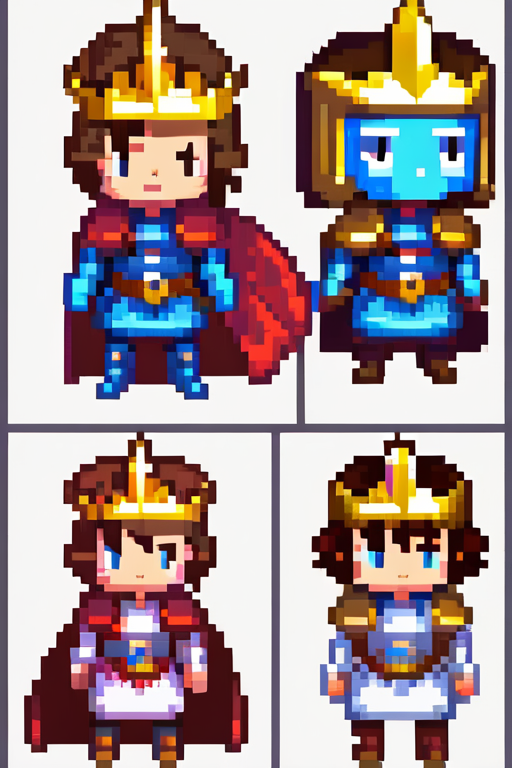

  0%|                                               | 0.00/176M [00:00<?, ?B/s]


Processed (64x96, shown at 4x):


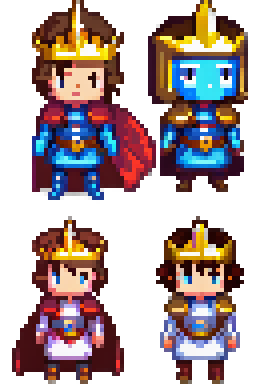

In [6]:
from IPython.display import display

meta = PROMPTS['_meta']
test_entry = PROMPTS['party'][0]  # hero
prompt, neg = build_prompt(test_entry, meta)
print(f'Prompt: {prompt[:150]}...')

result = pipe(prompt=prompt, negative_prompt=neg, width=512, height=768,
              num_inference_steps=28, guidance_scale=8.0)
print('Raw output:')
display(result.images[0])

test_img = postprocess(result.images[0])
# Show at 4x zoom for visibility
zoomed = test_img.resize((TARGET_W * 4, TARGET_H * 4), Image.NEAREST)
print(f'\nProcessed ({TARGET_W}x{TARGET_H}, shown at 4x):')
display(zoomed)
free_vram()

## 7. Generate Party Members (8 sprites)

~8-12s per character on T4

In [7]:
entries = PROMPTS['party']
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / 'overworld_characters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('owc_party', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\nParty: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, out_dir, tracker, steps=28, guidance=8.0)

print(f'\nDone!')

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['dark background, simple pixel art shading']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['dark background, simple pixel art shading']



Party: 8 total, 8 to generate

[1/8] 0/8 done
  [gen] char_hero (512x768 -> 64x96, 28 steps)


  0%|          | 0/28 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


        saved: char_hero.png (9 KB, 11.9s)

[2/8] 1/8 done
  [gen] char_elf (512x768 -> 64x96, 28 steps)


...

        saved: char_giant.png (10 KB, 15.2s)

[7/8] 6/8 done
  [gen] char_dwarf (512x768 -> 64x96, 28 steps)


  0%|          | 0/28 [00:00<?, ?it/s]

        saved: char_dwarf.png (8 KB, 11.8s)

[8/8] 7/8 done
  [gen] char_undead (512x768 -> 64x96, 28 steps)


  0%|          | 0/28 [00:00<?, ?it/s]

        saved: char_undead.png (8 KB, 11.9s)

Done!


## 8. Generate NPCs (5 sprites)

In [8]:
entries = PROMPTS['npcs']
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / 'overworld_characters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('owc_npcs', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\nNPCs: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, out_dir, tracker, steps=25, guidance=7.5)

print(f'\nDone!')


NPCs: 5 total, 5 to generate

[1/5] 0/5 done
  [gen] char_npc_shop (512x768 -> 64x96, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: char_npc_shop.png (10 KB, 10.9s)

[2/5] 1/5 done
  [gen] char_npc_quest (512x768 -> 64x96, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: char_npc_quest.png (9 KB, 10.9s)

[3/5] 2/5 done
  [gen] char_npc_save (512x768 -> 64x96, 25 steps)


...

        saved: char_npc_save.png (11 KB, 11.6s)

[4/5] 3/5 done
  [gen] char_npc_info (512x768 -> 64x96, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: char_npc_info.png (5 KB, 11.6s)

[5/5] 4/5 done
  [gen] char_npc_inn (512x768 -> 64x96, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: char_npc_inn.png (10 KB, 11.1s)

Done!


## 9. Generate Guard Base (1 sprite)

Single guard image — tinted per region at runtime by `AICharacterAssembler`.

In [9]:
entries = PROMPTS['guard']
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / 'overworld_characters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('owc_guard', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\nGuard: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, out_dir, tracker, steps=25, guidance=7.5)

print(f'\nDone!')


Guard: 1 total, 1 to generate

[1/1] 0/1 done
  [gen] char_guard (512x768 -> 64x96, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: char_guard.png (7 KB, 11.2s)

Done!


## 10. Quality Review — All Characters

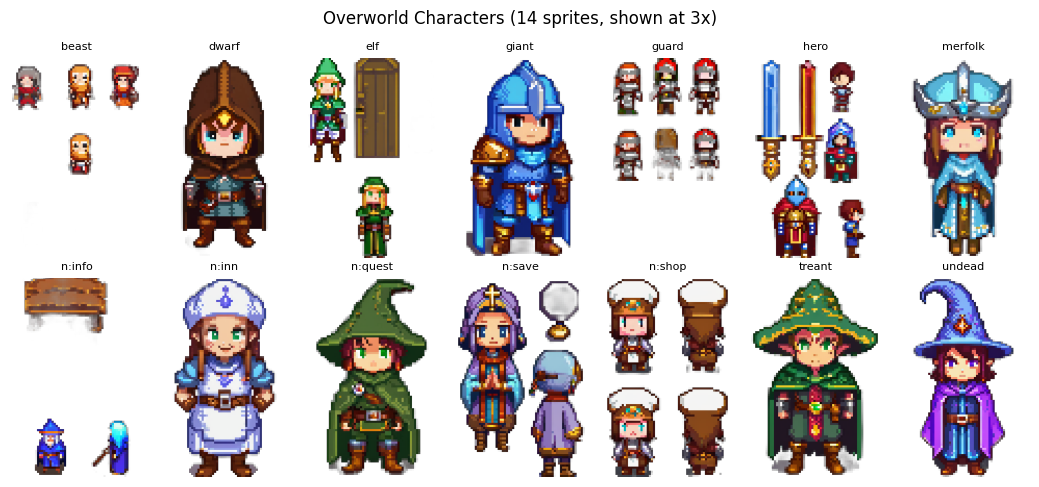

In [10]:
import matplotlib.pyplot as plt

out_dir = OUTPUT_BASE / 'overworld_characters'
pngs = sorted(out_dir.glob('*.png'))
pngs = [p for p in pngs if not p.stem.startswith('_')]

cols = 7
rows = (len(pngs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 2.5))
if rows == 1:
    axes = [axes]
for ax_row in axes:
    for ax in (ax_row if hasattr(ax_row, '__iter__') else [ax_row]):
        ax.axis('off')

for i, png in enumerate(pngs):
    r, c = i // cols, i % cols
    ax = axes[r][c] if rows > 1 else axes[0][c]
    img = Image.open(png)
    # Show at 3x for visibility
    img_zoom = img.resize((64 * 3, 96 * 3), Image.NEAREST)
    ax.imshow(img_zoom)
    label = png.stem.replace('char_', '').replace('npc_', 'n:')
    ax.set_title(label, fontsize=8)

plt.suptitle(f'Overworld Characters ({len(pngs)} sprites, shown at 3x)', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Export + Download

After downloading, import with:
```bash
bash scripts/import_colab_assets.sh ~/Downloads/overworld_output
bash scripts/force_restart_frontend.sh
```

In [11]:
import shutil

# Generate partial manifest for verification
d = OUTPUT_BASE / 'overworld_characters'
if d.exists():
    keys = sorted(f.stem for f in d.glob('*.png') if not f.stem.startswith('_'))
    print(f'overworld_characters: {len(keys)} sprites')
    for k in keys:
        print(f'  {k}')

zip_path = '/content/overworld_characters_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
print(f'\nZip: {os.path.getsize(zip_path + ".zip") / 1024:.1f} KB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')

overworld_characters: 14 sprites
  char_beast
  char_dwarf
  char_elf
  char_giant
  char_guard
  char_hero
  char_merfolk
  char_npc_info
  char_npc_inn
  char_npc_quest
  char_npc_save
  char_npc_shop
  char_treant
  char_undead

Zip: 43993.0 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>